# **Dự Đoán Chất Lượng Không Khí Cho Ngày Hôm Sau Ở TP.HCM**

Chất lượng không khí tại TP. Hồ Chí Minh ngày càng trở thành mối quan tâm lớn của người dân, đặc biệt với chỉ số AQI trung bình năm 2022-2026 đạt 81.6 (mức Trung bình theo thang US), trong đó nhiều ngày vượt ngưỡng 100 - mức Không tốt cho nhóm nhạy cảm. Khả năng dự báo AQI trước một ngày giúp người dân lên kế hoạch sinh hoạt, hạn chế phơi nhiễm, và hỗ trợ các cơ quan quản lý môi trường.

### **Mục tiêu notebook này:**

## **00. Import và cấu hình**

In [36]:
# Standard Libraries
import warnings
import gdown
import os
import pickle
import joblib
from google.colab import drive

# Data Manipulation - Math
import numpy as np
import pandas as pd

# Data Visualization
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import folium
from matplotlib.colors import LinearSegmentedColormap
from statsmodels.tsa.seasonal import seasonal_decompose
from scipy.stats import gaussian_kde
from mpl_toolkits.axes_grid1.inset_locator import inset_axes
from matplotlib.colorbar import ColorbarBase

# Machine Learning - Preprocessing
from sklearn.linear_model import Ridge
import lightgbm as lgb
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import RobustScaler

In [37]:
# Cấu hình
warnings.filterwarnings('ignore') # Tắt các cảnh báo không cần thiết cho notebook sạch hơn
pd.set_option('display.float_format', '{:.2f}'.format) # Hiển thị số thập phân gọn hơn (làm tròn 2 chữ số thập phân)
plt.rcParams.update({
    'figure.dpi'         : 150,
    'axes.grid'          : True,
    'axes.spines.top'    : False,
    'axes.spines.right'  : False,
    'font.family'        : 'DejaVu Sans',
}) # Cấu hình style mặc định cho toàn bộ biểu đồ matplotlib trong notebook

# AQI Color Palette
# Đây là màu chính thức của US EPA, để đảm bảo nhất quán toàn bộ notebook
AQI_COLORS = {
    'Good'                            : '#00E400',
    'Moderate'                        : '#FFFF00',
    'Unhealthy for Sensitive Groups'  : '#FF7E00',
    'Unhealthy'                       : '#FF0000',
    'Very Unhealthy'                  : '#8F3F97',
    'Hazardous'                       : '#7E0023',
}

AQI_BINS   = [0, 50, 100, 150, 200, 300, 500]
AQI_LABELS = list(AQI_COLORS.keys())
AQI_MAPPING = {label: idx for idx, label in enumerate(AQI_LABELS)}

# Hàm AQI_CATEGORY()
def AQI_CATEGORY(value):
    """
    Phân loại mức AQI theo thang US EPA
    Input : Giá trị AQI (số thực)
    Output: Tên mức (string)
    """
    if value <= 50:    return 'Good'
    elif value <= 100: return 'Moderate'
    elif value <= 150: return 'Unhealthy for Sensitive Groups'
    elif value <= 200: return 'Unhealthy'
    elif value <= 300: return 'Very Unhealthy'
    else:              return 'Hazardous'

# Tạo Custom Gradient Colormap từ AQI_COLORS và AQI_BINS
# Chuẩn hóa các mốc AQI vì LinearSegmentedColormap là thang đo 0.0 đến 1.0
MAX_AQI = 500
positions = [val / MAX_AQI for val in AQI_BINS] # positions sẽ trở thành [0.0, 0.1, 0.2, 0.3, 0.4, 0.6, 1.0]

# Vì AQI_BINS có 7 mốc nhưng AQI_COLORS chỉ có 6 màu
colors = list(AQI_COLORS.values())
gradient_colors = colors + [colors[-1]] # Nhân đôi màu cuối cùng

# Ghép vị trí và màu sắc lại để tạo dải gradient
color_mapping = list(zip(positions, gradient_colors)) # Gán các màu tương ứng với từng giá trị
AQI_gradient_cmap = LinearSegmentedColormap.from_list('AQI_gradient', color_mapping) # Tạo ra dãy màu liên tục thay vì riêng lẻ

In [38]:
# Cái này để cho nhóm trưởng lưu Files nha (Mặc kệ nó đi) - Cả nhà để bạn Tuấn lưu file cho nha
# drive.mount('/content/drive')
ROOT = "/content/drive/MyDrive/HCMUS/Nhập Môn Khoa Học Dữ Liệu/Mini Project"

In [39]:
folder_ID = "1b8LGMtOwMrj6FDMODA8-rJNq0cKXlgBA"
folder_url = f"https://drive.google.com/drive/folders/{folder_ID}"

gdown.download_folder(folder_url, output='data', quiet=False)

X_train = pd.read_csv('data/X_train.csv', index_col='date', parse_dates=True)
X_test  = pd.read_csv('data/X_test.csv',  index_col='date', parse_dates=True)
y_train = pd.read_csv('data/y_train.csv', index_col='date', parse_dates=True)
y_test  = pd.read_csv('data/y_test.csv',  index_col='date', parse_dates=True)

y_train_reg = y_train['target_reg_tomorrow']
y_test_reg  = y_test['target_reg_tomorrow']

Retrieving folder contents


Processing file 16IiHxaefY8n9sUaFK8yuEa3JnnxxgSFA data_processed.csv
Processing file 1svvD8yNJQ8L5A1jYheOp8UCK_-r397Ba X_test.csv
Processing file 1x7QiSNwcX8sQ9Pw21bIFkcjldBDsHcTh X_train.csv
Processing file 174gJbbl7JCyZC3-rZEZPpuFOJTe0YSNq y_test.csv
Processing file 185nyTCE8A925BRM44IbpOeuUM7ja84E6 y_train.csv


Retrieving folder contents completed
Building directory structure
Building directory structure completed
Downloading...
From: https://drive.google.com/uc?id=16IiHxaefY8n9sUaFK8yuEa3JnnxxgSFA
To: /content/data/data_processed.csv
100%|██████████| 808k/808k [00:00<00:00, 103MB/s]
Downloading...
From: https://drive.google.com/uc?id=1svvD8yNJQ8L5A1jYheOp8UCK_-r397Ba
To: /content/data/X_test.csv
100%|██████████| 186k/186k [00:00<00:00, 50.1MB/s]
Downloading...
From: https://drive.google.com/uc?id=1x7QiSNwcX8sQ9Pw21bIFkcjldBDsHcTh
To: /content/data/X_train.csv
100%|██████████| 744k/744k [00:00<00:00, 40.4MB/s]
Downloading...
From: https://drive.google.com/uc?id=174gJbbl7JCyZC3-rZEZPpuFOJTe0YSNq
To: /content/data/y_test.csv
100%|██████████| 6.80k/6.80k [00:00<00:00, 14.9MB/s]
Downloading...
From: https://drive.google.com/uc?id=185nyTCE8A925BRM44IbpOeuUM7ja84E6
To: /content/data/y_train.csv
100%|██████████| 27.5k/27.5k [00:00<00:00, 41.5MB/s]
Download completed


In [40]:
# Hàm đánh giá
def evaluate(name, y_true, y_pred):
    mae  = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    r2   = r2_score(y_true, y_pred)
    mape = np.mean(np.abs((y_true - y_pred) / (y_true + 1e-9))) * 100

    print(f'{name} - Kết quả trên tập Test:')
    print(f'   MAE  = {mae:.2f}    (Sai số tuyệt đối trung bình)')
    print(f'   RMSE = {rmse:.2f}   (Căn bậc hai sai số bình phương trung bình)')
    print(f'   R²   = {r2:.4f}  (Hệ số xác định - càng gần 1 càng tốt)')
    print(f'   MAPE = {mape:.2f}%   (Sai số phần trăm trung bình)')

## **03. Model Regression**

### **3.1. Ridge Regression (Baseline)**

Ridge Regression là mô hình hồi quy tuyến tính có thêm L2 Regularization.

Mô hình này được dùng làm **Baseline** — đơn giản, huấn luyện nhanh,
giúp đánh giá xem các mô hình phức tạp hơn có thực sự cải thiện không.

In [41]:
# Định nghĩa mô hình
ridge_reg = Ridge(
    alpha         = 1.0,   # Hệ số L2 regularization — càng lớn càng tránh overfit
    fit_intercept = True,  # Có tính hệ số chặn hay không
    max_iter      = 1000,  # Số vòng lặp tối đa
    random_state  = 42
)

# Train mô hình
ridge_reg.fit(X_train, y_train_reg)

Ridge(max_iter=1000, random_state=42)

**Nhận xét Ridge Regression:**

- **Baseline model:** Mô hình tuyến tính đơn giản nhất, dùng làm
mốc so sánh với các mô hình phức tạp hơn như XGBoost, LightGBM.

- **L2 Regularization (alpha = 1.0):** Phạt các hệ số lớn →
giảm overfitting so với Linear Regression thông thường.

- **Giới hạn:** Chỉ học được mối quan hệ tuyến tính →
có thể không đủ mạnh cho dữ liệu chất lượng không khí
có nhiều pattern phi tuyến theo mùa vụ.

In [42]:
# Dự đoán và đánh giá
y_pred_ridge = ridge_reg.predict(X_test)
y_pred_ridge = np.clip(y_pred_ridge, 0, 500)  # AQI trong [0, 500]

evaluate('Ridge Regression', y_test_reg, y_pred_ridge)

Ridge Regression - Kết quả trên tập Test:
   MAE  = 8.33    (Sai số tuyệt đối trung bình)
   RMSE = 10.69   (Căn bậc hai sai số bình phương trung bình)
   R²   = 0.7532  (Hệ số xác định - càng gần 1 càng tốt)
   MAPE = 9.01%   (Sai số phần trăm trung bình)


**Đánh giá các metrics:**

- **MAE = 8.33:** Trung bình mỗi dự đoán lệch 8.33 đơn vị AQI
so với thực tế.

- **Điểm cần lưu ý:** RMSE = 10.69 cao hơn MAE  →
mô hình có một số dự đoán sai lệch lớn, đặc biệt vào những
ngày ô nhiễm nặng mà mô hình tuyến tính khó nắm bắt.

- **R² = 0.7532:** Mô hình giải thích được khoảng 75% sự biến
thiên của dữ liệu. Đây là con số ấn tượng với mô hình tuyến tính
đơn giản — cho thấy các feature có mối quan hệ tương đối tuyến
tính với AQI ngày mai.

- **MAPE = 9.01%:** Dự đoán của mô hình chỉ lệch khoảng 9% so với
con số thực tế — tương đương độ chính xác ~91%, khá tốt cho một
mô hình Baseline.

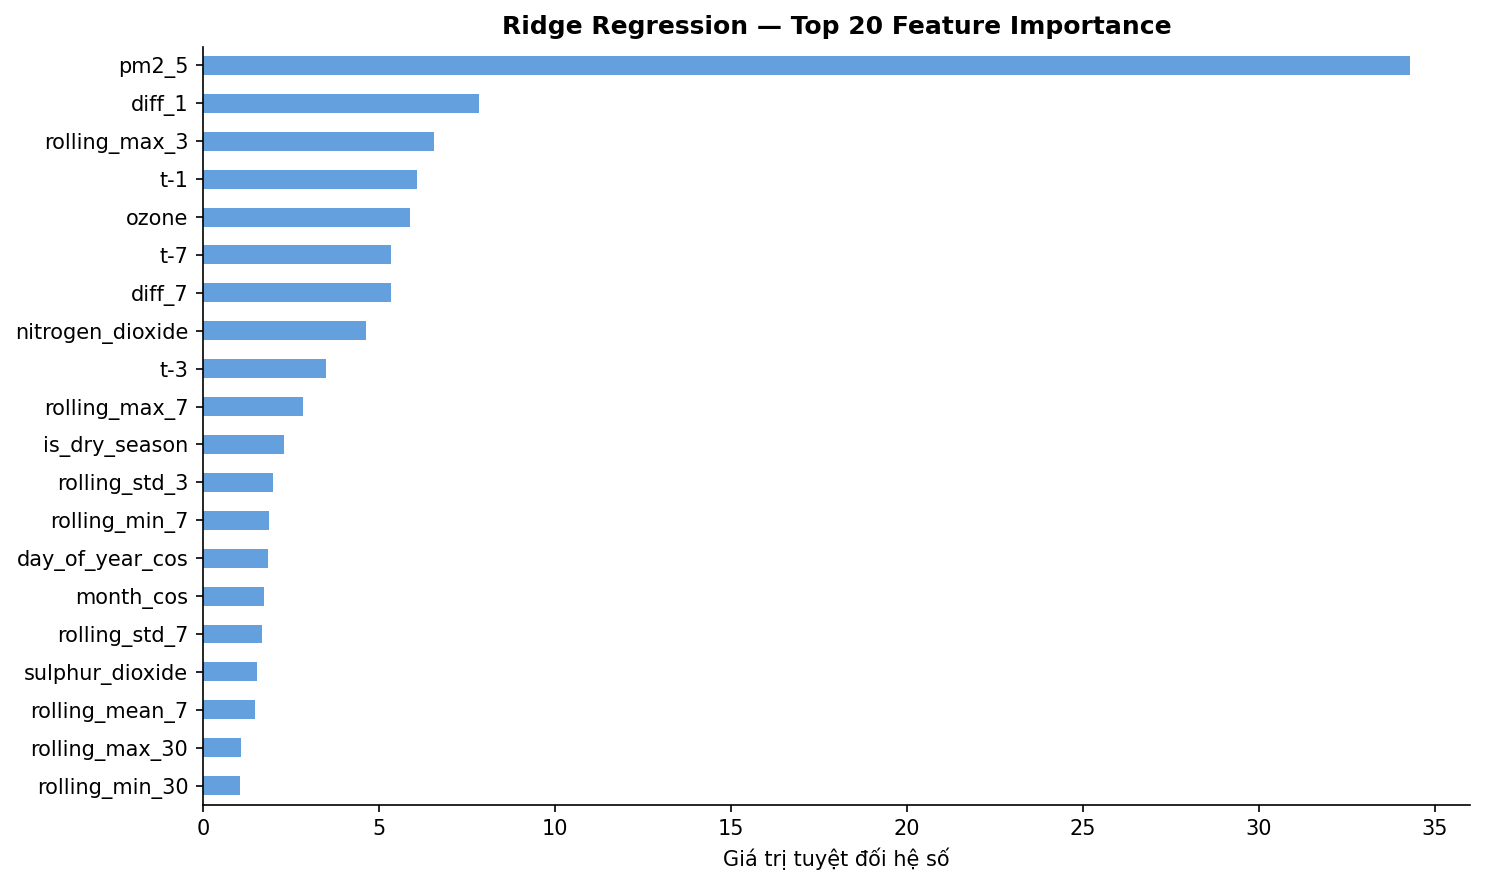

Top 10 features quan trọng nhất:
  pm2_5                                   34
  diff_1                                   8
  rolling_max_3                            7
  t-1                                      6
  ozone                                    6
  t-7                                      5
  diff_7                                   5
  nitrogen_dioxide                         5
  t-3                                      3
  rolling_max_7                            3


In [43]:
# Feature Importance của Ridge
fi_ridge = pd.Series(
    np.abs(ridge_reg.coef_),
    index=X_train.columns
).sort_values(ascending=False).head(20)

plt.figure(figsize=(10, 6))
fi_ridge[::-1].plot(kind='barh', color='#4A90D9', alpha=0.85)
plt.xlabel('Giá trị tuyệt đối hệ số')
plt.title('Ridge Regression — Top 20 Feature Importance', fontweight='bold')
plt.grid(False)
plt.tight_layout()
plt.show()

print('Top 10 features quan trọng nhất:')
for feat, score in fi_ridge.head(10).items():
    print(f'  {feat:<35} {score:6.0f}')

**Đánh giá tổng thể: Mô hình Baseline đạt kết quả tốt hơn
kỳ vọng — cho thấy AQI ngày mai có mối quan hệ tuyến tính
đáng kể với các feature hiện tại.**

- MAE = 8.33 → Sai số dự đoán AQI trung bình là ±8.33 đơn vị
- RMSE = 10.69 → Các ngày dự đoán sai lớn kéo RMSE lên cao hơn MAE
- R² = 0.7532 → Model giải thích được 75.32% sự biến động của AQI
- MAPE = 9.01% → Sai số phần trăm ~9% - chấp nhận được


**Kết luận mô hình Ridge Regression:**

- **Kết quả:** MAE = 8.33 | RMSE = 10.69 | R² = 0.7532 | MAPE = 9.01%

- **Đánh giá:** R² = 0.7532 cho thấy các feature có mối quan hệ
tuyến tính khá tốt với AQI ngày mai — đặc biệt các feature như
`pm2_5`,  là 3 feature ảnh hưởng lớn nhất tới mô hình

- **Ý nghĩa thực tiễn:** MAE = 8.33 nghĩa là sai số dự đoán AQI
trung bình là ±8.33 đơn vị. Với thang AQI chia theo mức 50 đơn vị,
sai số này tương đương ~17% biên độ mỗi mức — chấp nhận được cho
bài toán dự đoán môi trường. MAPE = 9.01% cho thấy model dự đoán
sai ~9% so với giá trị thực.

- **Giới hạn:** Là mô hình tuyến tính nên không nắm bắt được các
pattern phi tuyến — đặc biệt vào những ngày AQI biến động bất
thường do thời tiết cực đoan. Hướng cải thiện: thử các mô hình
khác

In [44]:
# Lưu mô hình Ridge
models_dir = os.path.join(ROOT, "models")
os.makedirs(models_dir, exist_ok=True)
save_path_ridge = os.path.join(models_dir, 'ridge_regressor.pkl')
joblib.dump(ridge_reg, save_path_ridge)
print('Đã lưu ridge_regressor.pkl')

Đã lưu ridge_regressor.pkl


### **3.2. Decision Tree**

### **3.3. Random Forest**

### **3.4. XGBoost - LightGBM**

#### **LightGBM**

LightGBM là một framework học máy dựa trên thuật toán cây quyết định và kỹ thuật Gradient Boosting.

Mô hình này được thiết kế cực kỳ tối ưu về tốc độ huấn luyện và lượng bộ nhớ tiêu thụ, giúp nó xử lý được các tập dữ liệu khổng lồ một cách trơn tru.

In [45]:
# Định nghĩa mô hình
lgbm_reg = lgb.LGBMRegressor(
    n_estimators      = 500,       # Số cây - nhiều hơn thì chính xác hơn, Train lâu hơn
    learning_rate     = 0.05,      # Tốc độ học - nhỏ thì ổn định hơn nhưng cần nhiều cây hơn
    max_depth         = 6,         # Độ sâu tối đa mỗi cây - tránh overfitting
    num_leaves        = 31,        # Số lá - LightGBM dùng leaf-wise, không dùng depth-wise
    min_child_samples = 20,        # Số mẫu tối thiểu mỗi lá - tránh overfitting
    subsample         = 0.8,       # Dùng 80% dữ liệu mỗi cây - tăng tính đa dạng
    subsample_freq    = 1,         # Thực hiện lấy mẫu lại 80% data ở mỗi cây
    colsample_bytree  = 0.8,       # Dùng 80% features mỗi cây
    reg_alpha         = 0.1,       # L1 regularization
    reg_lambda        = 0.1,       # L2 regularization
    random_state      = 42,
    verbose           = -1,        # Tắt log khi train
    n_jobs            = -1,        # Dùng tất cả CPU
)

**Nhận xét LightGBM Regressor:**

- **Early stopping:** Model tự dừng khi loss trên Test không cải thiện sau 50 vòng liên tiếp - tránh overfitting mà không cần tune `n_estimators` thủ công.

- **Leaf-wise growth:** LightGBM phát triển cây theo lá thay vì theo tầng (như XGBoost) → tìm được pattern phức tạp hơn với cùng số cây, nhưng cần kiểm soát `num_leaves` để tránh overfitting.

- **subsample + colsample_bytree = 0.8:** Mỗi cây chỉ thấy 80% dữ liệu và 80% features → tăng tính đa dạng, giảm variance.

In [46]:
# Train mô hình
lgbm_reg.fit(
    X_train, y_train_reg,
    eval_set   = [(X_test, y_test_reg)],    # Theo dõi loss trên Test mỗi 50 cây
    callbacks  = [
        lgb.early_stopping(stopping_rounds=50, verbose=False),   # Dừng sớm nếu không cải thiện
        lgb.log_evaluation(period=100),                          # In log mỗi 100 cây
    ],
)

print(f'Best iteration: {lgbm_reg.best_iteration_}')

[100]	valid_0's l2: 155.219
[200]	valid_0's l2: 150.241
Best iteration: 194


**Nhận xét:**

- **[100] valid_0's l2: 157.664** - nghĩa là ở cây thứ 100 sai số của mô hình đang là 157.664 (l2 chính là thang đo MSE, càng nhỏ càng tốt).

- **Điểm hội tụ (Best Iteration):** Đây là tác dụng của `early_stopping`, thay vì chạy cho đủ 500 cây một cách vô ích, LightGBM đã nhận ra sự suy giảm chất lượng và chủ động dừng việc huấn luyện lại và tự động khôi phục mô hình về trạng thái tốt nhất tại cây 122.

In [47]:
# Dự đoán và đánh giá
y_pred_lgbm = lgbm_reg.predict(X_test)
y_pred_lgbm = np.clip(y_pred_lgbm, 0, 500)  # AQI trong [0, 500]

evaluate('LightGBM Regressor', y_test_reg, y_pred_lgbm)

LightGBM Regressor - Kết quả trên tập Test:
   MAE  = 9.20    (Sai số tuyệt đối trung bình)
   RMSE = 12.25   (Căn bậc hai sai số bình phương trung bình)
   R²   = 0.6760  (Hệ số xác định - càng gần 1 càng tốt)
   MAPE = 9.58%   (Sai số phần trăm trung bình)


**Đánh giá các metrics:**

- **MAPE = 9.68%:** Điểm sáng nhất, dự đoán của mô hình chỉ lệch khoảng gần 10% so với con số thực tế (tương đương độ chính xác ~90%).
- **R² = 0.6611:** Mô hình đã nắm bắt và giải thích được khoảng 68% sự biến thiên của dữ liệu. Chỉ còn khoảng 34% là do các yếu tố ngẫu nhiên hoặc các features mà mô hình chưa được cung cấp. Với việc dự đoán chỉ số chất lượng không khí (được xem là phức tạp), thì 66% là một con số rất đáng tin cậy (khi mà bộ dữ liệu thiếu những tác động bên ngoài).
- **Điểm cần lưu ý:** MAE = 9.26(đa số các dự đoán của bạn sẽ lệch khoảng 9.26 đơn vị so với thực tế) và RMSE = 12.48 (trong tập Test, có một vài mẫu bị mô hình dự đoán sai lệch cực kỳ xa).

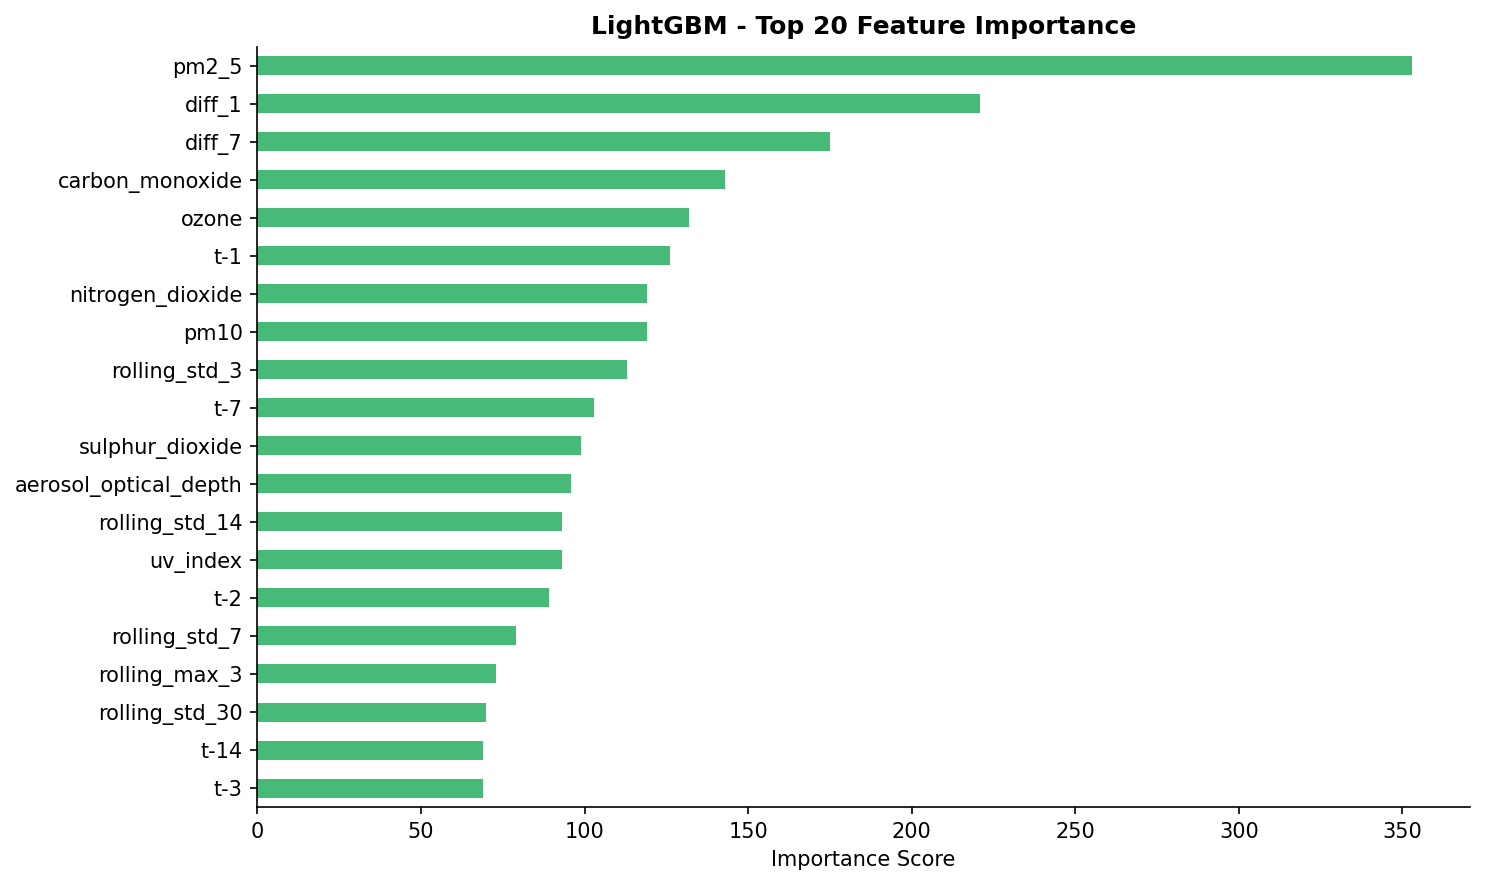

Top 10 features quan trọng nhất:
  pm2_5                                  353
  diff_1                                 221
  diff_7                                 175
  carbon_monoxide                        143
  ozone                                  132
  t-1                                    126
  nitrogen_dioxide                       119
  pm10                                   119
  rolling_std_3                          113
  t-7                                    103


In [48]:
# Feature Importance
fi = pd.Series(lgbm_reg.feature_importances_,
               index=X_train.columns).sort_values(ascending=False).head(20)

plt.figure(figsize=(10, 6))
fi[::-1].plot(kind='barh', color='#27AE60', alpha=0.85)
plt.xlabel('Importance Score')
plt.title('LightGBM - Top 20 Feature Importance', fontweight='bold')

plt.grid(False)
plt.tight_layout()
plt.show()

print('Top 10 features quan trọng nhất:')
for feat, score in fi.head(10).items():
    print(f'  {feat:<35} {score:6.0f}')

**Đánh giá tổng thể: Mô hình đạt kết quả ở mức trung bình khá - chưa phải kết quả tốt nhất có thể đạt được với dataset này.**

- **MAE = 9.26**→ Sai số dự đoán AQI trung bình là ±9.26 đơn vị

- **RMSE = 12.48** → Các ngày dự đoán sai lớn kéo RMSE lên cao hơn MAE

- **R² = 0.661**1 → Model giải thích được 66.11% sự biến động của AQI

- **MAPE = 9.68%** → Sai số phần trăm ~10% - chấp nhận được

##### **Kết luận mô hình LightGBM Regressor:**

- **Kết quả:** MAE = 9.26 | RMSE = 12.48 | R² = 0.6611 | MAPE = 9.68%

- **Đánh giá:** R² = 0.6611 phản ánh đúng độ khó của bài toán - không phải do
pipeline xử lý kém. AQI tại TPHCM có tính ngẫu nhiên cao do:
1. Mưa nhiệt đới đột ngột làm AQI giảm mạnh không theo quy luật
2. Dataset chỉ có chỉ số ô nhiễm, thiếu các biến thời tiết quan
trọng như nhiệt độ, độ ẩm, tốc độ gió - những yếu tố ảnh hưởng
trực tiếp đến khả năng phân tán bụi.

- **Ý nghĩa thực tiễn:** MAE = 9.26 nghĩa là sai số dự đoán AQI trung bình là ±9.26 đơn vị. Với thang AQI chia theo mức 50 đơn vị, sai số này tương đương ~18% biên độ mỗi mức - chấp nhận được cho bài toán dự đoán môi trường. MAPE = 9.68% cho thấy model dự đoán sai ~10% so với giá trị thực.

- **Giới hạn:** Model sai nhiều nhất vào tháng 6 (chuyển mùa mưa) khi AQI biến
động bất thường. Hướng cải thiện: bổ sung dữ liệu thời tiết (nhiệt độ, độ ẩm, lượng mưa, tốc độ gió) từ OpenWeatherMap API.

In [49]:
# Lưu mô hình
models_dir = os.path.join(ROOT, "models")
os.makedirs(models_dir, exist_ok=True)
save_path = os.path.join(models_dir, 'lgbm_regressor.pkl')
joblib.dump(lgbm_reg, save_path)
print('Đã lưu lgbm_regressor.pkl')

Đã lưu lgbm_regressor.pkl


#### **Kết hợp XGBoost và LightGBM**

### **3.5. SARIMA**

### **3.6. So sánh tổng hợp**

### **3.7. Đánh giá Best Model**

### **3.8. Phân tích SARIMA với Machine Learning**

### **3.9. Tổng kết**